In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta as beta_dist

np.set_printoptions(precision=6, suppress=True)

# Choose lambda.
lam = 1.0

# Choose utility U. Use nonlinear utilities for Problem (9) experiments.
def U(x):
    # return np.sqrt(np.maximum(x, 0.0))
    return np.log1p(np.maximum(x, 0.0))
    # return 1-np.exp(-10*x)
    # return np.minimum(x,2)

# Choose F, discretized on theta_grid with weights theta_weights.
distribution = "uniform"  # "uniform", "beta", or "custom"
theta_min = 0.5
theta_max = 1.0
n_theta = 200

# Used only when distribution == "beta".
beta_alpha = 2.0
beta_beta = 5.0

# Used only when distribution == "custom".
custom_theta = None
custom_weights = None

# Numerical settings.
x_max = 10.0
eps = 1e-8
n_random_starts = 2
seed = 123


In [2]:
def make_theta_grid(
    distribution,
    theta_min,
    theta_max,
    n_theta,
    *,
    beta_alpha=2.0,
    beta_beta=5.0,
    custom_theta=None,
    custom_weights=None,
):
    if distribution == "uniform":
        theta = np.linspace(theta_min, theta_max, n_theta)
        weights = np.ones(n_theta)   / n_theta
    elif distribution == "beta":
        u = np.linspace(0.0, 1.0, n_theta)
        theta = theta_min + (theta_max - theta_min) * beta_dist.ppf(u, beta_alpha, beta_beta)
        weights = np.ones(n_theta) / n_theta
    elif distribution == "custom":
        if custom_theta is None or custom_weights is None:
            raise ValueError("Provide custom_theta and custom_weights for distribution='custom'.")
        theta = np.asarray(custom_theta, dtype=float)
        weights = np.asarray(custom_weights, dtype=float)
        order = np.argsort(theta)
        theta = theta[order]
        weights = weights[order]
        weights = weights / weights.sum()
    else:
        raise ValueError("distribution must be 'uniform', 'beta', or 'custom'.")

    if len(theta) < 3:
        raise ValueError("Use at least three theta grid points.")
    if np.any(weights <= 0):
        raise ValueError("All quadrature weights must be positive.")
    return theta, weights


def tail_sums_from_x(x, weights):
    tail_x = np.cumsum((weights * x)[::-1])[::-1]
    tail_x2 = np.cumsum((weights * x**2)[::-1])[::-1]
    return tail_x, tail_x2


def evaluate_problem9_policy(x, theta, weights, lam, U_func, eps=1e-8):
    x = np.asarray(x, dtype=float)
    tail_x_inclusive, tail_x2_inclusive = tail_sums_from_x(x, weights)
    tail_x_exclusive = tail_x_inclusive - weights * x

    denom_inclusive = 1.0 - lam * tail_x_inclusive
    denom_exclusive = 1.0 - lam * tail_x_exclusive

    if np.any(x < -eps) or np.any(denom_inclusive <= eps) or np.any(denom_exclusive <= eps):
        return {"value": -np.inf}

    # Same grid type enters residual work, but does not preempt its own service.
    sojourn_time = (
        lam * tail_x2_inclusive / (denom_inclusive * denom_exclusive)
        + x / denom_exclusive
    )
    payoff = U_func(x) - theta * sojourn_time
    value = lam * np.dot(weights, payoff)

    return {
        "value": value,
        "x": x,
        "theta": theta,
        "weights": weights,
        "sojourn_time": sojourn_time,
        "payoff": payoff,
        "mean_x": np.dot(weights, x),
        "second_moment_x": np.dot(weights, x**2),
        "load": lam * np.dot(weights, x),
        "tail_x_inclusive": tail_x_inclusive,
        "tail_x_exclusive": tail_x_exclusive,
        "tail_x2_inclusive": tail_x2_inclusive,
        "denom_inclusive": denom_inclusive,
        "denom_exclusive": denom_exclusive,
        "denom": denom_inclusive,
    }


def clip_and_monotonize(x, x_max):
    x = np.clip(np.asarray(x, dtype=float), 0.0, x_max)
    return np.maximum.accumulate(x[::-1])[::-1]


def project_to_interior_stability(x, weights, lam, x_max, max_load=0.5):
    x = clip_and_monotonize(x, x_max)
    load = lam * np.dot(weights, x)
    if load > max_load:
        x = x * (max_load / load)
    return x


def make_initial_x(theta, weights, lam, x_max, kind, rng):
    u = (theta - theta.min()) / (theta.max() - theta.min())
    mean_cap = min(0.5 / lam, 0.8 * x_max)

    if kind == "flat":
        x0 = np.full_like(theta, mean_cap)
    elif kind == "linear":
        x0 = mean_cap * (1.5 - u)
    elif kind == "steep":
        x0 = mean_cap * (1.8 - 1.6 * u**2)
    elif kind == "inverse_theta":
        x0 = mean_cap * (theta.min() / theta)
    elif kind == "random":
        draws = rng.uniform(0.2, 1.8, size=len(theta)) * mean_cap
        x0 = np.sort(draws)[::-1]
    else:
        raise ValueError(f"Unknown initialization: {kind}")

    return project_to_interior_stability(x0, weights, lam, x_max)


def solve_problem9(
    theta,
    weights,
    lam,
    U_func,
    *,
    x_max=20.0,
    eps=1e-8,
    n_random=6,
    seed=123,
):
    theta = np.asarray(theta, dtype=float)
    weights = np.asarray(weights, dtype=float)
    rng = np.random.default_rng(seed)

    def objective(z):
        out = evaluate_problem9_policy(z, theta, weights, lam, U_func, eps=eps)
        if not np.isfinite(out["value"]):
            return 1e12
        return -out["value"]

    constraints = [
        {"type": "ineq", "fun": lambda z: z[:-1] - z[1:]},
        {"type": "ineq", "fun": lambda z: 1.0 - eps - lam * np.dot(weights, z)},
    ]
    bounds = [(0.0, x_max)] * len(theta)

    initializations = ["inverse_theta", "linear", "flat", "steep"] + ["random"] * n_random
    results = []

    for kind in initializations:
        x0 = make_initial_x(theta, weights, lam, x_max, kind, rng)
        res = minimize(
            objective,
            x0,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": 2000, "disp": False},
        )
        x_hat = clip_and_monotonize(res.x, x_max)
        load_hat = lam * np.dot(weights, x_hat)
        if load_hat >= 1.0 - eps:
            x_hat = x_hat * ((1.0 - 2.0 * eps) / load_hat)
        out = evaluate_problem9_policy(x_hat, theta, weights, lam, U_func, eps=eps)
        out.update(
            {
                "success": bool(res.success),
                "message": res.message,
                "initialization": kind,
                "nit": res.nit,
                "raw_result": res,
            }
        )
        results.append(out)

    finite_results = [r for r in results if np.isfinite(r["value"])]
    if not finite_results:
        raise RuntimeError("No feasible solution found. Try smaller x_max, smaller lambda, or more starts.")

    successful_results = [r for r in finite_results if r["success"]]
    candidate_results = successful_results if successful_results else finite_results
    best = max(candidate_results, key=lambda r: r["value"])
    return best, results


In [3]:
theta_grid, theta_weights = make_theta_grid(
    distribution,
    theta_min,
    theta_max,
    n_theta,
    beta_alpha=beta_alpha,
    beta_beta=beta_beta,
    custom_theta=custom_theta,
    custom_weights=custom_weights,
)

best, all_results = solve_problem9(
    theta_grid,
    theta_weights,
    lam,
    U,
    x_max=x_max,
    eps=eps,
    n_random=n_random_starts,
    seed=seed,
)

print(f"success: {best['success']}")
print(f"message: {best['message']}")
print(f"best initialization: {best['initialization']}")
print(f"objective value: {best['value']:.8f}")
print(f"E[x]: {best['mean_x']:.8f}")
print(f"lambda E[x]: {best['load']:.8f}")
print(f"max x: {best['x'].max():.8f}")


success: True
message: Optimization terminated successfully
best initialization: inverse_theta
objective value: 0.02859788
E[x]: 0.14902674
lambda E[x]: 0.14902674
max x: 0.69398607


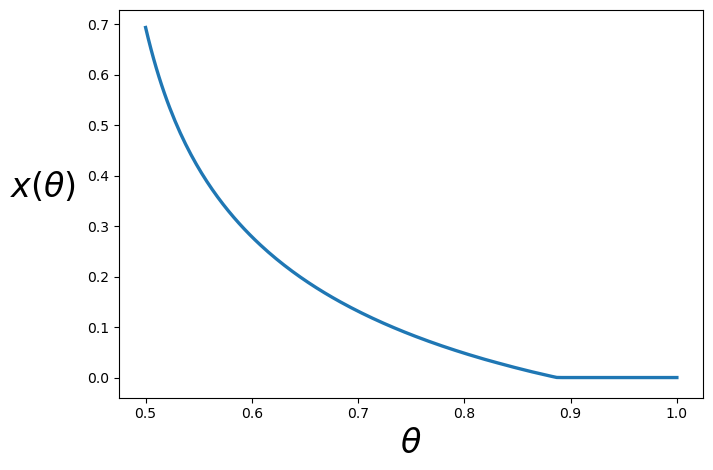

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(best["theta"], best["x"], linewidth=2.4)
ax.set_xlabel(r"$\theta$", fontsize=24)
ax.set_ylabel(r"$x(\theta)$", fontsize=24, rotation=0)
#ax.set_title("Optimal service-time allocation")
#ax.grid(alpha=0.3)
ax.set_ylim(bottom=-0.04)
ax.yaxis.set_label_coords(-0.13, 0.5)
fig.tight_layout()
fig.savefig("log_optimal_service_assigment.pdf")
plt.show()


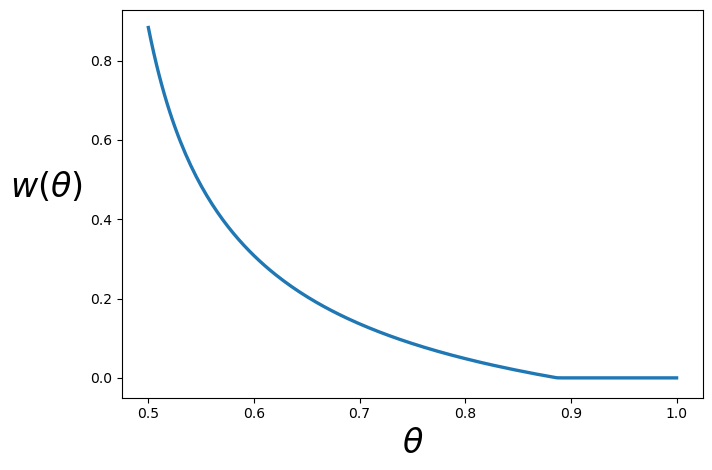

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(best["theta"], best["sojourn_time"], linewidth=2.4)
ax.set_xlabel(r"$\theta$", fontsize=24)
ax.set_ylabel(r"$w(\theta)$", fontsize=24, rotation=0)
#ax.set_title("Sojourn time by type")
#ax.grid(alpha=0.3)
ax.set_ylim(bottom=-0.05)
ax.yaxis.set_label_coords(-0.13, 0.5)
fig.tight_layout()
fig.savefig("log_sojourn_time.pdf")
plt.show()


minimum IC slack: -2.776e-17
minimum rent: 0.000e+00


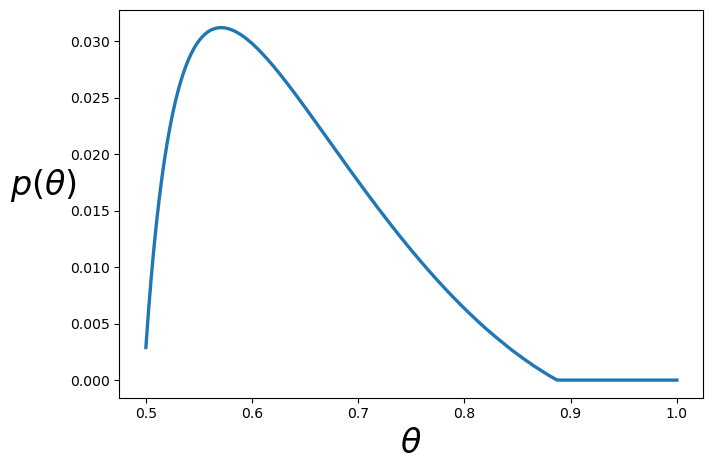

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))

theta = np.asarray(best["theta"], dtype=float)
x = np.asarray(best["x"], dtype=float)
w = np.asarray(best["sojourn_time"], dtype=float)

# Exact finite-type IC rents for the discretized grid.
# The highest-theta type receives zero rent; adjacent IC constraints bind downward.
rent = np.zeros_like(theta)
rent[:-1] = np.cumsum((np.diff(theta) * w[1:])[::-1])[::-1]

payment = U(x) - theta * w - rent

utility_if_choose_j = U(x)[None, :] - theta[:, None] * w[None, :] - payment[None, :]
ic_slack = np.diag(utility_if_choose_j) - np.max(utility_if_choose_j, axis=1)
print(f"minimum IC slack: {ic_slack.min():.3e}")
print(f"minimum rent: {rent.min():.3e}")

ax.plot(theta, payment, linewidth=2.4)
ax.set_xlabel(r"$\theta$", fontsize=24)
ax.set_ylabel(r"$p(\theta)$", fontsize=24, rotation=0)
#ax.set_ylim(bottom=0.0)
ax.yaxis.set_label_coords(-0.13, 0.5)
#ax.set_title("Payment by type")
#ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("log_payment.pdf")
plt.show()


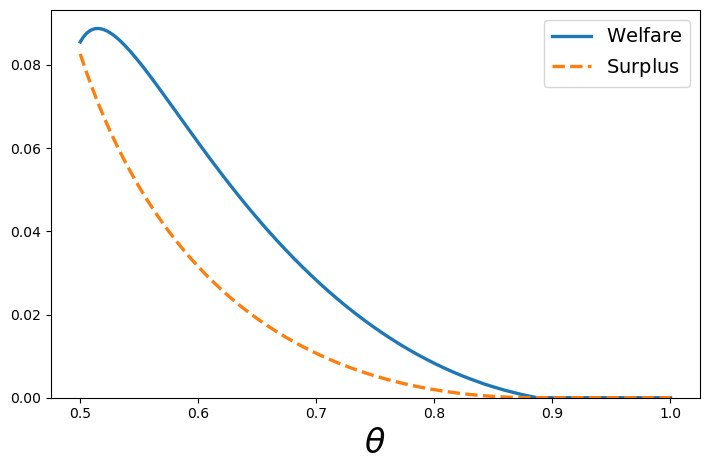

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))

theta = np.asarray(best["theta"], dtype=float)
x = np.asarray(best["x"], dtype=float)
w = np.asarray(best["sojourn_time"], dtype=float)

# Centralized reward excludes payments. Decentralized reward is customer surplus after payment.
rent = np.zeros_like(theta)
rent[:-1] = np.cumsum((np.diff(theta) * w[1:])[::-1])[::-1]
payment = U(x) - theta * w - rent

centralized_reward = U(x) - theta * w
decentralized_reward = centralized_reward - payment

ax.plot(theta, centralized_reward, linewidth=2.4, label=r"$\text{Welfare}$")
ax.plot(theta, decentralized_reward, linewidth=2.4, linestyle="--", label=r"$\text{Surplus}$")
ax.set_xlabel(r"$\theta$", fontsize=24)
#ax.set_ylabel("reward", fontsize=22)
ax.set_ylim(bottom=0.0)
ax.legend(fontsize=14)
#ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("log_reward_comparison.pdf")
plt.show()
